In [1]:
# Hybrid RF + MLP Pipeline with Tuning, Preprocessing Variants,

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from typing import Dict, Any, List, Tuple

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    classification_report, roc_auc_score
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

import joblib
np.random.seed(42)

In [2]:

DATA_PATH = "../results/outputs/scaled.csv"   # change if needed
TARGET_COL = "Status"

data = pd.read_csv(DATA_PATH)
assert TARGET_COL in data.columns, f"Target column '{TARGET_COL}' not found."

X = data.drop(columns=[TARGET_COL])
y = data[TARGET_COL]

print(f"✅ Dataset: {X.shape[0]} samples, {X.shape[1]} features.")
print("Class distribution:\n", y.value_counts())

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
classes = np.unique(y_train)
num_classes = len(classes)

✅ Dataset: 15000 samples, 20 features.
Class distribution:
 Status
0    5000
1    5000
2    5000
Name: count, dtype: int64


In [5]:

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

preproc_A = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="mean")),
            ("scale", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("encode", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

preproc_B = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", MinMaxScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("encode", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))
        ]), cat_cols),
    ],
    remainder="drop"
)

In [6]:

def macro_ovr_auc(y_true, proba, labels) -> float:
    """Macro AUC OvR; works for binary or multiclass."""
    Y = label_binarize(y_true, classes=labels)
    # Handle binary shape
    if proba.shape[1] == 1:
        proba = np.hstack([1 - proba, proba])
    return roc_auc_score(Y, proba, multi_class='ovr', average='macro')

def evaluate_classifier(clf, X_te, y_te, labels, name="Model") -> Dict[str, Any]:
    pred = clf.predict(X_te)
    acc = accuracy_score(y_te, pred)
    prec = precision_score(y_te, pred, average="weighted", zero_division=0)
    rec = recall_score(y_te, pred, average="weighted", zero_division=0)
    f1 = f1_score(y_te, pred, average="weighted", zero_division=0)
    # proba for AUC
    if hasattr(clf, "predict_proba"):
        proba = clf.predict_proba(X_te)
        auc = macro_ovr_auc(y_te, proba, labels)
    else:
        auc = np.nan

    print(f"\n=== {name} ===")
    print("Accuracy:", round(acc, 4))
    print("Precision (weighted):", round(prec, 4))
    print("Recall (weighted):", round(rec, 4))
    print("F1 (weighted):", round(f1, 4))
    if not np.isnan(auc):
        print("Macro AUC (OvR):", round(auc, 4))
    print("\nConfusion Matrix:\n", confusion_matrix(y_te, pred))
    print("\nClassification Report:\n", classification_report(y_te, pred, zero_division=0))

    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "AUC": auc}


In [7]:

def rf_grid(preprocessor):
    pipe = Pipeline([
        ("prep", preprocessor),
        ("rf", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
    ])

    param_grid = {
        "rf__n_estimators": [200, 300, 400],
        "rf__max_depth": [None, 10, 20, 30],
        "rf__min_samples_split": [2, 5, 10],
        "rf__min_samples_leaf": [1, 2, 4],
        "rf__bootstrap": [True, False],
        # You can also try: "rf__max_features": ["sqrt", "log2", None],
    }

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="f1_weighted",
        cv=skf,
        n_jobs=-1,
        verbose=1
    )
    return gs

def rf_base(preprocessor):
    return Pipeline([
        ("prep", preprocessor),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ])

results: List[Dict[str, Any]] = []
cv_rows = []

# Variant A: Base RF
rfA_base = rf_base(preproc_A)
rfA_base.fit(X_train, y_train)
results.append(evaluate_classifier(rfA_base, X_test, y_test, classes, name="RF Base (Preproc A)"))
cv_f1 = cross_val_score(rfA_base, X_train, y_train, cv=skf, scoring="f1_weighted", n_jobs=-1).mean()
cv_rows.append(("RF Base (Preproc A)", cv_f1))

# Variant A: Grid RF
rfA_gs = rf_grid(preproc_A)
rfA_gs.fit(X_train, y_train)
print("\nBest params (RF Grid, Preproc A):", rfA_gs.best_params_)
rfA_best = rfA_gs.best_estimator_
results.append(evaluate_classifier(rfA_best, X_test, y_test, classes, name="RF Grid (Preproc A)"))
cv_f1 = cross_val_score(rfA_best, X_train, y_train, cv=skf, scoring="f1_weighted", n_jobs=-1).mean()
cv_rows.append(("RF Grid (Preproc A)", cv_f1))

# Variant B: Base RF
rfB_base = rf_base(preproc_B)
rfB_base.fit(X_train, y_train)
results.append(evaluate_classifier(rfB_base, X_test, y_test, classes, name="RF Base (Preproc B)"))
cv_f1 = cross_val_score(rfB_base, X_train, y_train, cv=skf, scoring="f1_weighted", n_jobs=-1).mean()
cv_rows.append(("RF Base (Preproc B)", cv_f1))

# Variant B: Grid RF
rfB_gs = rf_grid(preproc_B)
rfB_gs.fit(X_train, y_train)
print("\nBest params (RF Grid, Preproc B):", rfB_gs.best_params_)
rfB_best = rfB_gs.best_estimator_
results.append(evaluate_classifier(rfB_best, X_test, y_test, classes, name="RF Grid (Preproc B)"))
cv_f1 = cross_val_score(rfB_best, X_train, y_train, cv=skf, scoring="f1_weighted", n_jobs=-1).mean()
cv_rows.append(("RF Grid (Preproc B)", cv_f1))


=== RF Base (Preproc A) ===
Accuracy: 0.9817
Precision (weighted): 0.9817
Recall (weighted): 0.9817
F1 (weighted): 0.9817
Macro AUC (OvR): 0.999

Confusion Matrix:
 [[982   1  17]
 [  3 990   7]
 [ 26   1 973]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98      1000
           1       1.00      0.99      0.99      1000
           2       0.98      0.97      0.97      1000

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best params (RF Grid, Preproc A): {'rf__bootstrap': False, 'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}

=== RF Grid (Preproc A) ===
Accuracy: 0.9843
Precision (weighted): 0.9844
Recall (weighted): 0.9843
F1 (weighted): 0.9843
Macro AUC (OvR): 0.9992

Confusi

In [8]:
# Pick the better of rfA_best vs rfB_best by CV F1
best_rf_name, best_rf_pipe = max(
    [("RF Grid (Preproc A)", rfA_best), ("RF Grid (Preproc B)", rfB_best)],
    key=lambda tup: cross_val_score(tup[1], X_train, y_train, cv=skf, scoring="f1_weighted", n_jobs=-1).mean()
)
print(f"\n🔗 Using {best_rf_name} as RF stacker in Hybrid.")

# Out-of-fold RF probabilities for TRAIN (avoid leakage)
rf_oof_proba = cross_val_predict(best_rf_pipe, X_train, y_train, cv=skf, method="predict_proba", n_jobs=-1)

# Extract the preprocessor from the chosen RF pipe to transform raw features consistently
chosen_preproc = best_rf_pipe.named_steps["prep"]
X_train_trans = chosen_preproc.fit_transform(X_train, y_train)
X_test_trans = chosen_preproc.transform(X_test)

# RF proba on TEST from the fully-fitted best RF
best_rf_pipe.fit(X_train, y_train)
rf_test_proba = best_rf_pipe.predict_proba(X_test)

# Hybrid features = [preprocessed features | RF proba]
X_train_hybrid = np.hstack([X_train_trans, rf_oof_proba])
X_test_hybrid = np.hstack([X_test_trans, rf_test_proba])

# Scale hybrid inputs for MLP
hybrid_scaler = StandardScaler(with_mean=False)  # sparse-safe
X_train_hybrid = hybrid_scaler.fit_transform(X_train_hybrid)
X_test_hybrid = hybrid_scaler.transform(X_test_hybrid)

# One-hot labels for multiclass MLP
if num_classes > 2:
    y_train_nn = to_categorical(pd.Series(y_train).map({c:i for i,c in enumerate(classes)}), num_classes)
    y_test_idx = pd.Series(y_test).map({c:i for i,c in enumerate(classes)}).values
else:
    y_train_nn = pd.Series(y_train).map({classes[0]:0, classes[1]:1}).values
    y_test_idx = pd.Series(y_test).map({classes[0]:0, classes[1]:1}).values

input_dim = X_train_hybrid.shape[1]

def build_mlp(hidden1=256, hidden2=128, drop=0.3):
    model = Sequential([
        Dense(hidden1, input_dim=input_dim, activation="relu"),
        BatchNormalization(),
        Dropout(drop),
        Dense(hidden2, activation="relu"),
        BatchNormalization(),
        Dropout(drop),
        Dense(num_classes, activation="softmax" if num_classes>2 else "sigmoid")
    ])
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy" if num_classes>2 else "binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Small manual search for MLP
mlp_configs = [
    (256, 128, 0.3),
    (256, 64,  0.3),
    (128, 64,  0.2),
]

best_mlp = None
best_val = -np.inf
best_cfg = None

for h1, h2, dp in mlp_configs:
    mlp = build_mlp(hidden1=h1, hidden2=h2, drop=dp)
    es = EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True, verbose=0)
    hist = mlp.fit(
        X_train_hybrid, y_train_nn,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        verbose=0,
        callbacks=[es]
    )
    val_acc = max(hist.history["val_accuracy"])
    print(f"MLP config (h1={h1}, h2={h2}, drop={dp}) -> best val_acc={val_acc:.4f}")
    if val_acc > best_val:
        best_val = val_acc
        best_mlp = mlp
        best_cfg = (h1, h2, dp)

print(f"\nBest MLP config: hidden1={best_cfg[0]}, hidden2={best_cfg[1]}, dropout={best_cfg[2]} (val_acc={best_val:.4f})")

# Evaluate Hybrid on TEST
mlp_pred = best_mlp.predict(X_test_hybrid, verbose=0)
if num_classes == 2:
    y_pred_idx = (mlp_pred > 0.5).astype(int).reshape(-1)
else:
    y_pred_idx = np.argmax(mlp_pred, axis=1)

# Map indices back to original labels for reporting
idx_to_label = {i:c for i,c in enumerate(classes)}
y_pred_lbl = pd.Series(y_pred_idx).map(idx_to_label).values

# Metrics for Hybrid
acc = accuracy_score(y_test, y_pred_lbl)
prec = precision_score(y_test, y_pred_lbl, average="weighted", zero_division=0)
rec = recall_score(y_test, y_pred_lbl, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred_lbl, average="weighted", zero_division=0)

# AUC macro OvR: need probabilities in class order
if num_classes == 2:
    proba_for_auc = np.vstack([1-mlp_pred.reshape(-1), mlp_pred.reshape(-1)]).T
else:
    proba_for_auc = mlp_pred
auc = macro_ovr_auc(y_test, proba_for_auc, classes)

print("\n=== Hybrid (RF + MLP) ===")
print("Accuracy:", round(acc,4))
print("Precision (weighted):", round(prec,4))
print("Recall (weighted):", round(rec,4))
print("F1 (weighted):", round(f1,4))
print("Macro AUC (OvR):", round(auc,4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lbl))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lbl, zero_division=0))

results.append({"Model": "Hybrid RF + MLP", "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "AUC": auc})



🔗 Using RF Grid (Preproc A) as RF stacker in Hybrid.
MLP config (h1=256, h2=128, drop=0.3) -> best val_acc=0.9887
MLP config (h1=256, h2=64, drop=0.3) -> best val_acc=0.9875
MLP config (h1=128, h2=64, drop=0.2) -> best val_acc=0.9883

Best MLP config: hidden1=256, hidden2=128, dropout=0.3 (val_acc=0.9887)

=== Hybrid (RF + MLP) ===
Accuracy: 0.9867
Precision (weighted): 0.9867
Recall (weighted): 0.9867
F1 (weighted): 0.9867
Macro AUC (OvR): 0.9989

Confusion Matrix:
 [[986   3  11]
 [  2 995   3]
 [ 21   0 979]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      1000
           1       1.00      0.99      1.00      1000
           2       0.99      0.98      0.98      1000

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000




=== 📊 Test Set Results ===
                 Model  Accuracy  Precision    Recall        F1       AUC
4      Hybrid RF + MLP  0.986667   0.986700  0.986667  0.986672  0.998905
3  RF Grid (Preproc B)  0.984333   0.984377  0.984333  0.984345  0.999175
1  RF Grid (Preproc A)  0.984333   0.984377  0.984333  0.984345  0.999174
0  RF Base (Preproc A)  0.981667   0.981742  0.981667  0.981689  0.999029
2  RF Base (Preproc B)  0.981667   0.981742  0.981667  0.981689  0.999030

=== 🧪 Cross-Validation (Train) F1 (weighted) ===
                 Model  CV F1 (weighted)
1  RF Grid (Preproc A)          0.985848
3  RF Grid (Preproc B)          0.985848
0  RF Base (Preproc A)          0.983857
2  RF Base (Preproc B)          0.983857


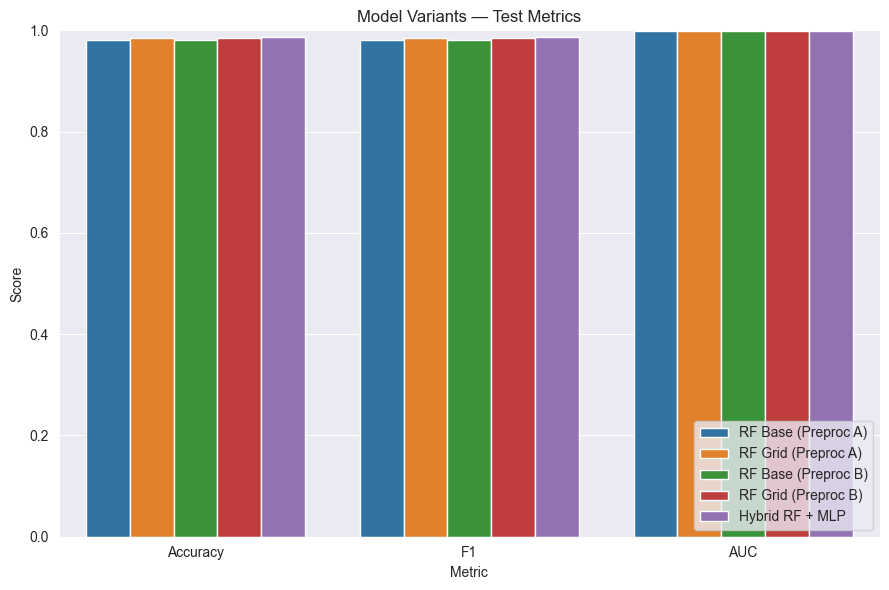

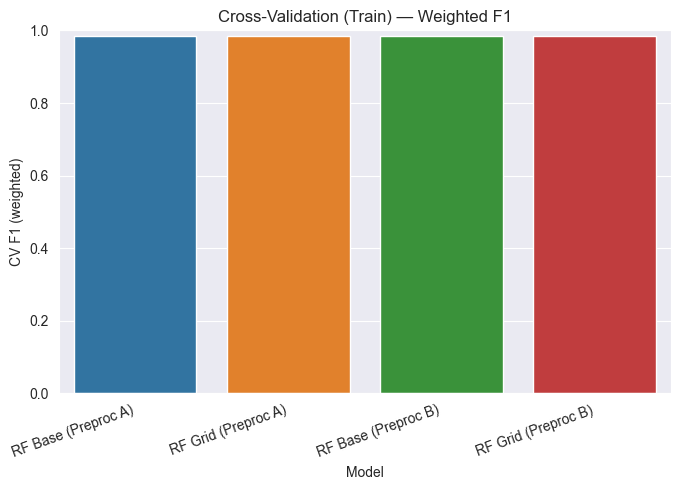

In [9]:

results_df = pd.DataFrame(results)
cv_df = pd.DataFrame(cv_rows, columns=["Model", "CV F1 (weighted)"])

print("\n=== 📊 Test Set Results ===")
print(results_df.sort_values("F1", ascending=False))

print("\n=== 🧪 Cross-Validation (Train) F1 (weighted) ===")
print(cv_df.sort_values("CV F1 (weighted)", ascending=False))

# Bar plots
plt.figure(figsize=(9,6))
melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=melted[melted["Metric"].isin(["Accuracy","F1","AUC"])],
            x="Metric", y="Score", hue="Model")
plt.title("Model Variants — Test Metrics")
plt.ylim(0.0, 1.0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.barplot(data=cv_df, x="Model", y="CV F1 (weighted)", hue="Model", legend=False)
plt.title("Cross-Validation (Train) — Weighted F1")
plt.ylim(0.0, 1.0)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [10]:

best_row = results_df.iloc[results_df["F1"].idxmax()]
best_name = best_row["Model"]
print(f"\n🏆 Best by test F1: {best_name}")

os.makedirs("artifacts", exist_ok=True)

if best_name == "Hybrid RF + MLP":
    # Save both RF (best pipe) and MLP + scaler
    joblib.dump(best_rf_pipe, "artifacts/best_rf_pipe.pkl")
    joblib.dump(hybrid_scaler, "artifacts/hybrid_scaler.pkl")
    best_mlp.save("artifacts/hybrid_mlp.keras")
    print("Saved: artifacts/best_rf_pipe.pkl, artifacts/hybrid_scaler.pkl, artifacts/hybrid_mlp.keras")
else:
    # Save the winning RF pipeline
    name_to_pipe = {
        "RF Base (Preproc A)": rfA_base,
        "RF Grid (Preproc A)": rfA_best,
        "RF Base (Preproc B)": rfB_base,
        "RF Grid (Preproc B)": rfB_best
    }
    joblib.dump(name_to_pipe[best_name], "artifacts/best_rf_pipeline.pkl")
    print("Saved: artifacts/best_rf_pipeline.pkl")

print("\n✅ Done.")



🏆 Best by test F1: Hybrid RF + MLP
Saved: artifacts/best_rf_pipe.pkl, artifacts/hybrid_scaler.pkl, artifacts/hybrid_mlp.keras

✅ Done.
